# Open-Water Validation (Fig. 7a-d, Supp. Fig. 5, Supp. Table 1)

Validates the AdDSWE open-water classification against stratified visual-interpretation
points (five sensor eras x four hydrological phases; n = 1,420). Builds the class-specific
and binary error matrices, accuracy by stratum, and the **Fig. 7a-d** comparison panels.

- **Produces:** Supplementary Table 1 (stratified accuracy), Supplementary Fig. 5, Fig. 7a-d.
- **Inputs:** validation points and results (Dryad `inundation/open_water_validation/`).

> Input/output paths are set within the notebook (to be pointed at a local Dryad copy).


In [ ]:
import os

# =============================== PATH CONFIGURATION ===============================
# Point DRYAD_ROOT at your local copy of the Dryad archive (doi:10.5061/dryad.msbcc2gct).
DRYAD_ROOT = r"."            # e.g. r"E:\Okavango\Data\For_Dryad"
OUTPUT_DIR = r"./outputs"    # local folder for derived CSVs / figures
os.makedirs(OUTPUT_DIR, exist_ok=True)


# Open Water AdDSWE Validation


## Inspection of individual QC/validation points over RGB composites and AdDSWE classification raster

In [4]:
import ee
import pandas as pd
from datetime import datetime
from IPython.display import display, Image as IPImage
import ipywidgets as widgets

ee.Initialize()

# Configuration
VALIDATION_YEAR = 2007
CURRENT_MONTH = '01'  # July
POINTS_ASSET = 'projects/ee-okavango/assets/water_masks/monthly_DSWE_Landsat_30m_v4/OpenWater_Validation/validation_points_70_manual_2008'
RGB_PATH_TEMPLATE = 'projects/ee-okavango/assets/water_masks/monthly_DSWE_Landsat_30m_v4/Source_LS_Composites/Composite_{year}_{month}'
DSWE_PATH_TEMPLATE = 'projects/ee-okavango/assets/water_masks/monthly_DSWE_Landsat_30m_v4/DSWE_Products/DSWE_{year}_{month}'
RESULTS_CSV = os.path.join(DRYAD_ROOT, "inundation", "open_water_validation", "validation_results_2008.csv")

# Month names for display
MONTH_NAMES = {'04': 'April', '07': 'July', '10': 'October', '12': 'December'}

# Load data
validation_points = ee.FeatureCollection(POINTS_ASSET)
points_list = validation_points.getInfo()['features']

try:
    results_df = pd.read_csv(RESULTS_CSV)
    print(f"Loaded existing results: {len(results_df)} classifications")
except FileNotFoundError:
    results_df = pd.DataFrame(columns=['Point_ID', 'Year', 'Month', 'Visual_Classification', 'Confidence_Flag', 'DSWE_Value', 'Timestamp'])
    print("Created new results DataFrame")

# Load imagery
rgb_composite = ee.Image(RGB_PATH_TEMPLATE.format(year=VALIDATION_YEAR, month=CURRENT_MONTH))
dswe_product = ee.Image(DSWE_PATH_TEMPLATE.format(year=VALIDATION_YEAR, month=CURRENT_MONTH))

rgb_vis = {'bands': ['Red', 'Green', 'Blue'], 'min': 0.0, 'max': 0.3, 'gamma': 1.3}
dswe_vis = {'min': 0, 'max': 4, 'palette': ['#D2B48C', '#BFDFFF', '#7FBFFF', '#3F8FFF', '#004F8F']}

# State
current_idx = 0
zoom_level = 1  # 1x = 250m buffer, 2x = 500m buffer, etc.

def show_point(idx):
    global current_idx, zoom_level
    current_idx = idx
    point = points_list[idx]
    coords = point['geometry']['coordinates']
    props = point['properties']
    
    # Create point geometry and region with current zoom level
    point_geom = ee.Geometry.Point(coords)
    buffer_distance = 250 * zoom_level  # Scale buffer by zoom level
    region = point_geom.buffer(buffer_distance).bounds()
    
    # Create visible marker - red circle with white outline
    marker = ee.FeatureCollection([
        ee.Feature(point_geom.buffer(15)),
        ee.Feature(point_geom.buffer(10))
    ])
    
    white_circle = ee.Image().paint(marker.limit(1), 1, 3)
    red_circle = ee.Image().paint(marker.limit(1, 'system:index', False), 1, 3)
    
    marker_overlay = white_circle.visualize(palette=['FFFFFF']).blend(
                     red_circle.visualize(palette=['FF0000']))
    
    rgb_with_marker = rgb_composite.visualize(**rgb_vis).blend(marker_overlay)
    dswe_with_marker = dswe_product.visualize(**dswe_vis).blend(marker_overlay)
    
    rgb_url = rgb_with_marker.getThumbURL({'region': region, 'dimensions': 512})
    dswe_url = dswe_with_marker.getThumbURL({'region': region, 'dimensions': 512})
    
    month_name = MONTH_NAMES.get(CURRENT_MONTH, CURRENT_MONTH)
    info_text.value = f"<b>Point {props['Point_ID']}</b> ({idx+1}/{len(points_list)}) - <b>{month_name} {VALIDATION_YEAR}</b> [Zoom: {zoom_level}x]<br>DSWE Values: Apr={props.get('DSWE_04')}, Jul={props.get('DSWE_07')}, Oct={props.get('DSWE_10')}, Dec={props.get('DSWE_12')}"
    
    rgb_img.value = f'<img src="{rgb_url}" width="400"><br>RGB Composite'
    dswe_img.value = f'<img src="{dswe_url}" width="400"><br>AdDSWE Product'

def zoom_out(b):
    global zoom_level
    zoom_level += 1
    show_point(current_idx)

def reset_zoom():
    global zoom_level
    zoom_level = 1

def classify(classification):
    global results_df, current_idx
    point = points_list[current_idx]
    new_row = {
        'Point_ID': point['properties']['Point_ID'],
        'Year': VALIDATION_YEAR,
        'Month': CURRENT_MONTH,
        'Visual_Classification': classification,
        'Confidence_Flag': confidence_toggle.value,
        'DSWE_Value': point['properties'].get(f'DSWE_{CURRENT_MONTH}'),
        'Timestamp': datetime.now().isoformat()
    }
    results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)
    if len(results_df) % 5 == 0:
        results_df.to_csv(RESULTS_CSV, index=False)
        print(f"Auto-saved: {len(results_df)} classifications")
    reset_zoom()  # Reset zoom when moving to next point
    if current_idx < len(points_list) - 1:
        show_point(current_idx + 1)

# Widgets
info_text = widgets.HTML()
rgb_img = widgets.HTML()
dswe_img = widgets.HTML()
confidence_toggle = widgets.ToggleButtons(options=['Certain', 'Uncertain'], value='Certain', description='Confidence:')
btn_water = widgets.Button(description='Open Water', button_style='info')
btn_not_water = widgets.Button(description='Not Open Water', button_style='warning')
btn_prev = widgets.Button(description='← Prev')
btn_next = widgets.Button(description='Next →')
btn_zoom_out = widgets.Button(description='🔍 Zoom Out', button_style='')

btn_water.on_click(lambda b: classify('Open Water'))
btn_not_water.on_click(lambda b: classify('Not Open Water'))
btn_prev.on_click(lambda b: (reset_zoom(), show_point(max(0, current_idx-1))))
btn_next.on_click(lambda b: (reset_zoom(), show_point(min(len(points_list)-1, current_idx+1))))
btn_zoom_out.on_click(zoom_out)

display(widgets.VBox([
    info_text,
    widgets.HBox([rgb_img, dswe_img]),
    confidence_toggle,
    widgets.HBox([btn_water, btn_not_water]),
    widgets.HBox([btn_prev, btn_next, btn_zoom_out])
]))

show_point(0)
print("Validation interface ready!")

Loaded existing results: 225 classifications


Validation interface ready!


## Confusion matrix analysis

Total classifications: 300
Unique points: 75
Months covered: [ 1  4  7 10]

Confidence breakdown:
Confidence_Flag
Certain      254
Uncertain     46
Name: count, dtype: int64


BINARY CLASSIFICATION ANALYSIS (Open Water vs Not Open Water)

Overall Accuracy: 0.9233 (92.33%)
Cohen's Kappa: 0.8437

Open Water Class:
  Producer's Accuracy (Recall): 0.8895 (88.95%)
  User's Accuracy (Precision): 0.9817 (98.17%)

Not Open Water Class:
  Producer's Accuracy: 0.9748 (97.48%)
  User's Accuracy: 0.8529 (85.29%)

Error Breakdown:
  True Positives (Correct Open Water): 161
  True Negatives (Correct Not Open Water): 116
  False Positives (Incorrectly classified as Open Water): 3
  False Negatives (Missed Open Water): 20
  Omission Error (Open Water): 11.05%
  Commission Error (Open Water): 1.83%


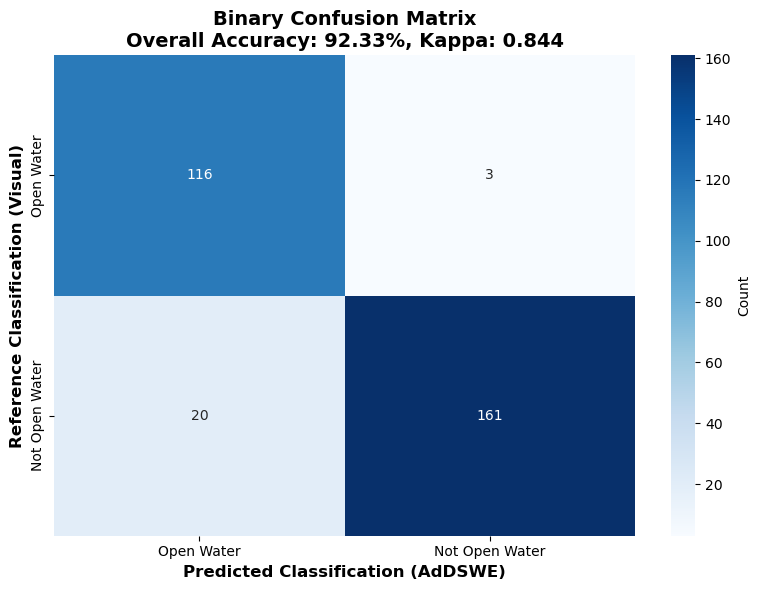



CLASS-SPECIFIC ERROR MATRIX

Class-Specific Breakdown:
(Rows = Visual Reference, Columns = AdDSWE Class)
                Class 0  Class 1  Class 2  Class 3  Class 4
Open Water            0        1        2       23       93
Not Open Water       66       41       54       18        2


Per-Class Analysis:

AdDSWE Class 0:
  Total pixels: 66
  Classified as Open Water: 0 (0.0%)
  Classified as Not Open Water: 66 (100.0%)
  Class Accuracy: 100.00% (correctly identified as Not Open Water)

AdDSWE Class 1:
  Total pixels: 42
  Classified as Open Water: 1 (2.4%)
  Classified as Not Open Water: 41 (97.6%)
  Class Accuracy: 97.62% (correctly identified as Not Open Water)

AdDSWE Class 2:
  Total pixels: 56
  Classified as Open Water: 2 (3.6%)
  Classified as Not Open Water: 54 (96.4%)
  Class Accuracy: 96.43% (correctly identified as Not Open Water)

AdDSWE Class 3:
  Total pixels: 41
  Classified as Open Water: 23 (56.1%)
  Classified as Not Open Water: 18 (43.9%)
  Class Accuracy: 56.10% 

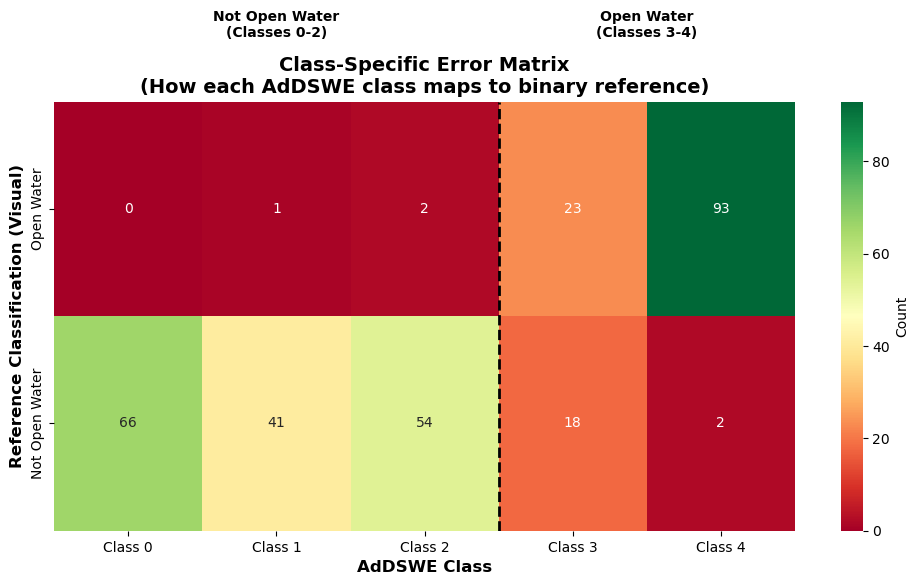



STRATIFIED ACCURACY ANALYSIS

Accuracy by Month:
  Month 1: Accuracy = 96.00%, Kappa = 0.911, n = 75
  Month 4: Accuracy = 92.00%, Kappa = 0.838, n = 75
  Month 7: Accuracy = 89.33%, Kappa = 0.789, n = 75
  Month 10: Accuracy = 92.00%, Kappa = 0.833, n = 75

Accuracy by Confidence Flag:
  Certain: Accuracy = 96.46%, Kappa = 0.925, n = 254
  Uncertain: Accuracy = 69.57%, Kappa = 0.374, n = 46

Misclassified Points:
  Total misclassified: 23 (7.67%)

Misclassification breakdown by DSWE class:
DSWE_Value
1     1
2     2
3    18
4     2
Name: count, dtype: int64

Analysis complete! Figures saved to validation directory.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, cohen_kappa_score, accuracy_score

# ============================================================================
# LOAD AND PREPARE DATA
# ============================================================================

# Load validation results
RESULTS_CSV = os.path.join(DRYAD_ROOT, "inundation", "open_water_validation", "validation_results_2008.csv")
df = pd.read_csv(RESULTS_CSV)

print(f"Total classifications: {len(df)}")
print(f"Unique points: {df['Point_ID'].nunique()}")
print(f"Months covered: {df['Month'].unique()}")
print(f"\nConfidence breakdown:")
print(df['Confidence_Flag'].value_counts())
print("\n" + "="*70 + "\n")

# Create binary predicted classifications from DSWE values
# Classes 3-4 = "Open Water", Classes 0-2 = "Not Open Water"
df['Predicted_Binary'] = df['DSWE_Value'].apply(
    lambda x: 'Open Water' if x in [3, 4] else 'Not Open Water'
)

# ============================================================================
# BINARY CONFUSION MATRIX AND METRICS
# ============================================================================

print("BINARY CLASSIFICATION ANALYSIS (Open Water vs Not Open Water)")
print("="*70)

# Get reference and predicted labels
y_true = df['Visual_Classification']
y_pred = df['Predicted_Binary']

# Calculate confusion matrix
cm_binary = confusion_matrix(y_true, y_pred, labels=['Open Water', 'Not Open Water'])

# Calculate metrics
overall_accuracy = accuracy_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)

# Calculate producer's and user's accuracies
tp, fn, fp, tn = cm_binary.ravel()

producers_accuracy_water = tp / (tp + fn)  # Sensitivity/Recall for Open Water
users_accuracy_water = tp / (tp + fp)  # Precision for Open Water

producers_accuracy_not_water = tn / (tn + fp)
users_accuracy_not_water = tn / (tn + fn)

print(f"\nOverall Accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"\nOpen Water Class:")
print(f"  Producer's Accuracy (Recall): {producers_accuracy_water:.4f} ({producers_accuracy_water*100:.2f}%)")
print(f"  User's Accuracy (Precision): {users_accuracy_water:.4f} ({users_accuracy_water*100:.2f}%)")
print(f"\nNot Open Water Class:")
print(f"  Producer's Accuracy: {producers_accuracy_not_water:.4f} ({producers_accuracy_not_water*100:.2f}%)")
print(f"  User's Accuracy: {users_accuracy_not_water:.4f} ({users_accuracy_not_water*100:.2f}%)")

print(f"\nError Breakdown:")
print(f"  True Positives (Correct Open Water): {tp}")
print(f"  True Negatives (Correct Not Open Water): {tn}")
print(f"  False Positives (Incorrectly classified as Open Water): {fp}")
print(f"  False Negatives (Missed Open Water): {fn}")
print(f"  Omission Error (Open Water): {fn/(tp+fn)*100:.2f}%")
print(f"  Commission Error (Open Water): {fp/(tp+fp)*100:.2f}%")

# Plot binary confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Open Water', 'Not Open Water'],
            yticklabels=['Open Water', 'Not Open Water'],
            cbar_kws={'label': 'Count'}, ax=ax)
ax.set_xlabel('Predicted Classification (AdDSWE)', fontsize=12, fontweight='bold')
ax.set_ylabel('Reference Classification (Visual)', fontsize=12, fontweight='bold')
ax.set_title(f'Binary Confusion Matrix\nOverall Accuracy: {overall_accuracy*100:.2f}%, Kappa: {kappa:.3f}', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "binary_confusion_matrix.png"), dpi=1000)
plt.show()

print("\n" + "="*70 + "\n")

# ============================================================================
# CLASS-SPECIFIC ERROR MATRIX
# ============================================================================

print("CLASS-SPECIFIC ERROR MATRIX")
print("="*70)

# Create class-specific confusion matrix
cm_class = confusion_matrix(y_true, df['DSWE_Value'], 
                            labels=['Open Water', 'Not Open Water'])

# Transpose to show DSWE classes as columns
# Rows = Reference (Visual), Columns = DSWE Class Values
class_labels = sorted(df['DSWE_Value'].unique())
cm_detailed = pd.DataFrame(0, 
                           index=['Open Water', 'Not Open Water'],
                           columns=[f'Class {i}' for i in range(5)])

# Fill in the matrix
for idx, row in df.iterrows():
    ref = row['Visual_Classification']
    dswe_class = row['DSWE_Value']
    cm_detailed.loc[ref, f'Class {dswe_class}'] += 1

print("\nClass-Specific Breakdown:")
print("(Rows = Visual Reference, Columns = AdDSWE Class)")
print(cm_detailed)

# Calculate class-specific statistics
print("\n\nPer-Class Analysis:")
for dswe_class in range(5):
    class_col = f'Class {dswe_class}'
    total_class = cm_detailed[class_col].sum()
    if total_class > 0:
        open_water_count = cm_detailed.loc['Open Water', class_col]
        not_water_count = cm_detailed.loc['Not Open Water', class_col]
        
        print(f"\nAdDSWE Class {dswe_class}:")
        print(f"  Total pixels: {total_class}")
        print(f"  Classified as Open Water: {open_water_count} ({open_water_count/total_class*100:.1f}%)")
        print(f"  Classified as Not Open Water: {not_water_count} ({not_water_count/total_class*100:.1f}%)")
        
        # Accuracy of this class
        if dswe_class in [3, 4]:  # Should be Open Water
            correct = open_water_count
            print(f"  Class Accuracy: {correct/total_class*100:.2f}% (correctly identified as Open Water)")
        else:  # Should be Not Open Water
            correct = not_water_count
            print(f"  Class Accuracy: {correct/total_class*100:.2f}% (correctly identified as Not Open Water)")

# Plot class-specific confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.heatmap(cm_detailed, annot=True, fmt='d', cmap='RdYlGn', 
            cbar_kws={'label': 'Count'}, ax=ax)
ax.set_xlabel('AdDSWE Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Reference Classification (Visual)', fontsize=12, fontweight='bold')
ax.set_title('Class-Specific Error Matrix\n(How each AdDSWE class maps to binary reference)', 
             fontsize=14, fontweight='bold')

# Add vertical line to separate classes 0-2 from 3-4
ax.axvline(x=3, color='black', linestyle='--', linewidth=2)
ax.text(1.5, -0.3, 'Not Open Water\n(Classes 0-2)', ha='center', fontsize=10, fontweight='bold')
ax.text(4, -0.3, 'Open Water\n(Classes 3-4)', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_specific_matrix.png"), dpi=1000)
plt.show()

print("\n" + "="*70 + "\n")

# ============================================================================
# STRATIFIED ANALYSES
# ============================================================================

print("STRATIFIED ACCURACY ANALYSIS")
print("="*70)

# By month
print("\nAccuracy by Month:")
for month in sorted(df['Month'].unique()):
    month_df = df[df['Month'] == month]
    month_acc = accuracy_score(month_df['Visual_Classification'], month_df['Predicted_Binary'])
    month_kappa = cohen_kappa_score(month_df['Visual_Classification'], month_df['Predicted_Binary'])
    print(f"  Month {month}: Accuracy = {month_acc*100:.2f}%, Kappa = {month_kappa:.3f}, n = {len(month_df)}")

# By confidence flag
print("\nAccuracy by Confidence Flag:")
for conf in df['Confidence_Flag'].unique():
    conf_df = df[df['Confidence_Flag'] == conf]
    conf_acc = accuracy_score(conf_df['Visual_Classification'], conf_df['Predicted_Binary'])
    conf_kappa = cohen_kappa_score(conf_df['Visual_Classification'], conf_df['Predicted_Binary'])
    print(f"  {conf}: Accuracy = {conf_acc*100:.2f}%, Kappa = {conf_kappa:.3f}, n = {len(conf_df)}")

# Misclassification summary
print("\nMisclassified Points:")
misclassified = df[df['Visual_Classification'] != df['Predicted_Binary']]
print(f"  Total misclassified: {len(misclassified)} ({len(misclassified)/len(df)*100:.2f}%)")
print(f"\nMisclassification breakdown by DSWE class:")
print(misclassified['DSWE_Value'].value_counts().sort_index())

print("\n" + "="*70)
print("Analysis complete! Figures saved to validation directory.")

## Figures showing accuracy of open water validation

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, cohen_kappa_score, accuracy_score

# Set Arial font globally
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 8
plt.rcParams['font.weight'] = 'normal'
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'normal'

# ============================================================================
# LOAD AND COMBINE ALL VALIDATION RESULTS
# ============================================================================

BASE_PATH = os.path.join(DRYAD_ROOT, "inundation", "open_water_validation") + os.sep
years = [1994, 2000, 2007, 2008, 2009, 2015, 2024]

dfs = []
for year in years:
    try:
        df_year = pd.read_csv(f'{BASE_PATH}validation_results_{year}.csv')
        dfs.append(df_year)
        print(f"Loaded {year}: {len(df_year)} classifications")
    except FileNotFoundError:
        pass

df_all = pd.concat(dfs, ignore_index=True)
df_all['Predicted_Binary'] = df_all['DSWE_Value'].apply(
    lambda x: 'Open Water' if x in [3, 4] else 'Not Open Water'
)

print(f"\n{'='*70}")
print(f"COMBINED VALIDATION DATASET")
print(f"{'='*70}")
print(f"Total classifications: {len(df_all)}")
print(f"Years: {sorted(df_all['Year'].unique())}")
print(f"Months: {sorted(df_all['Month'].unique())}")
print(f"\n{'='*70}\n")

# ============================================================================
# CALCULATE OVERALL METRICS
# ============================================================================

y_true = df_all['Visual_Classification']
y_pred = df_all['Predicted_Binary']

cm_binary = confusion_matrix(y_true, y_pred, labels=['Open Water', 'Not Open Water'])
tp = cm_binary[0, 0]  # Reference OW, Predicted OW
fn = cm_binary[0, 1]  # Reference OW, Predicted NOW
fp = cm_binary[1, 0]  # Reference NOW, Predicted OW
tn = cm_binary[1, 1]  # Reference NOW, Predicted NOW

overall_accuracy = accuracy_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)
producers_acc = tp / (tp + fn)
users_acc = tp / (tp + fp)

print(f"OVERALL VALIDATION METRICS (n={len(df_all)})")
print(f"{'='*70}")
print(f"Overall Accuracy:           {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"Cohen's Kappa:              {kappa:.4f}")
print(f"\nOpen Water Class (Classes 3-4):")
print(f"  Producer's Accuracy:      {producers_acc:.4f} ({producers_acc*100:.2f}%)")
print(f"  User's Accuracy:          {users_acc:.4f} ({users_acc*100:.2f}%)")
print(f"\n{'='*70}\n")

# ============================================================================
# CALCULATE STRATIFIED METRICS
# ============================================================================

df_all['Year_Group'] = df_all['Year'].apply(lambda x: '2008' if x in [2007, 2008, 2009] else str(x))

year_metrics = []
for year_group in ['1994', '2000', '2008', '2015', '2024']:
    df_year = df_all[df_all['Year_Group'] == year_group]
    if len(df_year) > 0:
        acc = accuracy_score(df_year['Visual_Classification'], df_year['Predicted_Binary'])
        kap = cohen_kappa_score(df_year['Visual_Classification'], df_year['Predicted_Binary'])
        n = len(df_year)
        year_metrics.append({'Year': year_group, 'Accuracy': acc, 'Kappa': kap, 'n': n})

year_metrics_df = pd.DataFrame(year_metrics)
year_std = year_metrics_df['Accuracy'].std()

df_all['Month_Group'] = df_all['Month'].apply(lambda x: 'Low' if x in [1, 12] else x)

month_metrics = []
for month_group in ['Low', 4, 7, 10]:
    df_month = df_all[df_all['Month_Group'] == month_group]
    if len(df_month) > 0:
        acc = accuracy_score(df_month['Visual_Classification'], df_month['Predicted_Binary'])
        kap = cohen_kappa_score(df_month['Visual_Classification'], df_month['Predicted_Binary'])
        n = len(df_month)
        month_metrics.append({'Month': month_group, 'Accuracy': acc, 'Kappa': kap, 'n': n})

month_metrics_df = pd.DataFrame(month_metrics)
month_std = month_metrics_df['Accuracy'].std()

# ============================================================================
# CLASS-SPECIFIC BREAKDOWN
# ============================================================================

class_matrix = pd.DataFrame(0, index=['Open Water', 'Not Open Water'],
                            columns=[f'Class {i}' for i in range(5)])
class_pct = pd.DataFrame(0.0, index=['Open Water', 'Not Open Water'],
                         columns=[f'Class {i}' for i in range(5)])

for idx, row in df_all.iterrows():
    ref = row['Visual_Classification']
    dswe_class = row['DSWE_Value']
    class_matrix.loc[ref, f'Class {dswe_class}'] += 1

for col in class_matrix.columns:
    total = class_matrix[col].sum()
    if total > 0:
        class_pct[col] = class_matrix[col] / total

# Find min/max for correct and incorrect to scale colors
correct_pcts = []
incorrect_pcts = []

for i, ref_class in enumerate(['Open Water', 'Not Open Water']):
    for j, dswe_class in enumerate(range(5)):
        col_name = f'Class {j}'
        pct = class_pct.loc[ref_class, col_name]
        
        if dswe_class in [3, 4]:
            is_correct = (ref_class == 'Open Water')
        else:
            is_correct = (ref_class == 'Not Open Water')
        
        if pct > 0:
            if is_correct:
                correct_pcts.append(pct)
            else:
                incorrect_pcts.append(pct)

min_correct = min(correct_pcts) if correct_pcts else 0
max_correct = max(correct_pcts) if correct_pcts else 1
min_incorrect = min(incorrect_pcts) if incorrect_pcts else 0
max_incorrect = max(incorrect_pcts) if incorrect_pcts else 1

# ============================================================================
# PANEL A: BINARY CONFUSION MATRIX
# ============================================================================

fig_a = plt.figure(figsize=(2.167, 2.167))
ax1 = fig_a.add_subplot(111)
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Open\nWater', 'Not\nOpen Water'],
            yticklabels=['Open\nWater', 'Not\nOpen Water'],
            cbar_kws={'label': 'Count'}, ax=ax1, annot_kws={'size': 8})
ax1.set_xlabel('Predicted (AdDSWE)', fontsize=8)
ax1.set_ylabel('Reference (Visual)', fontsize=8)
ax1.set_title(f'Binary Confusion Matrix\nOA={overall_accuracy*100:.1f}%, κ={kappa:.3f}', fontsize=8, pad=8)
ax1.tick_params(labelsize=8)
ax1.collections[0].colorbar.ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/panel_A_confusion_matrix.png', dpi=1000, bbox_inches='tight')
plt.savefig(f'{OUTPUT_DIR}/panel_A_confusion_matrix.pdf', bbox_inches='tight')
plt.close()

# ============================================================================
# PANEL B: TEMPORAL CONSISTENCY
# ============================================================================

fig_b = plt.figure(figsize=(2.167, 2.167))
ax2 = fig_b.add_subplot(111)
colors_year = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bars = ax2.bar(range(len(year_metrics_df)), year_metrics_df['Accuracy']*100, 
               color=colors_year, edgecolor='black', linewidth=1)
ax2.axhline(y=overall_accuracy*100, color='red', linestyle='--', linewidth=1.5, label='Overall')
ax2.set_xticks(range(len(year_metrics_df)))
ax2.set_xticklabels(year_metrics_df['Year'], fontsize=8)
ax2.set_ylabel('Accuracy (%)', fontsize=8)
ax2.set_xlabel('Validation Year', fontsize=8)
ax2.set_ylim([80, 100])
ax2.grid(axis='y', alpha=0.3)
ax2.legend(loc='lower right', fontsize=7)
ax2.set_title(f'Temporal Consistency (σ={year_std*100:.1f}%)', fontsize=8, pad=8)
ax2.tick_params(labelsize=8)

for i, (bar, row) in enumerate(zip(bars, year_metrics_df.itertuples())):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.3,
             f'n={row.n}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/panel_B_temporal.png', dpi=1000, bbox_inches='tight')
plt.savefig(f'{OUTPUT_DIR}/panel_B_temporal.pdf', bbox_inches='tight')
plt.close()

# ============================================================================
# PANEL C: SEASONAL CONSISTENCY
# ============================================================================

fig_c = plt.figure(figsize=(2.167, 2.167))
ax3 = fig_c.add_subplot(111)
month_label_list = ['Low\n(Jan/Dec)', 'Rise\n(Apr)', 'Peak\n(Jul)', 'Recess\n(Oct)']
colors_month = ['#CD853F', '#90EE90', '#4169E1', '#FFD700']

bars = ax3.bar(range(len(month_metrics_df)), month_metrics_df['Accuracy']*100,
               color=colors_month, edgecolor='black', linewidth=1)
ax3.axhline(y=overall_accuracy*100, color='red', linestyle='--', linewidth=1.5, label='Overall')
ax3.set_xticks(range(len(month_metrics_df)))
ax3.set_xticklabels(month_label_list, fontsize=8)
ax3.set_ylabel('Accuracy (%)', fontsize=8)
ax3.set_xlabel('Hydrological Period', fontsize=8)
ax3.set_ylim([80, 100])
ax3.grid(axis='y', alpha=0.3)
ax3.legend(loc='lower right', fontsize=7)
ax3.set_title(f'Seasonal Consistency (σ={month_std*100:.1f}%)', fontsize=8, pad=8)
ax3.tick_params(labelsize=8)

for i, (bar, row) in enumerate(zip(bars, month_metrics_df.itertuples())):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.3,
             f'n={row.n}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/panel_C_seasonal.png', dpi=1000, bbox_inches='tight')
plt.savefig(f'{OUTPUT_DIR}/panel_C_seasonal.pdf', bbox_inches='tight')
plt.close()

# ============================================================================
# PANEL D: CLASS-SPECIFIC ERROR MATRIX
# ============================================================================

fig_d = plt.figure(figsize=(6.5, 2))
ax4 = fig_d.add_subplot(111)

color_matrix = np.zeros((2, 5, 3))

for i, ref_class in enumerate(['Open Water', 'Not Open Water']):
    for j, dswe_class in enumerate(range(5)):
        col_name = f'Class {dswe_class}'
        pct = class_pct.loc[ref_class, col_name]
        
        if dswe_class in [3, 4]:
            is_correct = (ref_class == 'Open Water')
        else:
            is_correct = (ref_class == 'Not Open Water')
        
        if pct == 0:
            color_matrix[i, j] = [1, 1, 1]
        elif is_correct:
            if max_correct > min_correct:
                intensity = (pct - min_correct) / (max_correct - min_correct)
            else:
                intensity = 1.0
            color_matrix[i, j] = [0.7 - intensity*0.7, 1.0 - intensity*0.5, 0.7 - intensity*0.7]
        else:
            if max_incorrect > min_incorrect:
                intensity = (pct - min_incorrect) / (max_incorrect - min_incorrect)
            else:
                intensity = 1.0
            color_matrix[i, j] = [1.0 - intensity*0.2, 0.7 - intensity*0.7, 0.7 - intensity*0.7]

for i in range(2):
    for j in range(5):
        count = class_matrix.iloc[i, j]
        pct = class_pct.iloc[i, j]
        color = color_matrix[i, j]
        
        ax4.add_patch(plt.Rectangle((j, i), 1, 1, facecolor=color, edgecolor='black', linewidth=1))
        if count > 0:
            ax4.text(j + 0.5, i + 0.5, f'{count}\n({pct*100:.1f}%)', 
                    ha='center', va='center', fontsize=8)

ax4.set_xlim(0, 5)
ax4.set_ylim(0, 2)
ax4.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5])
ax4.set_xticklabels(['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4'], fontsize=8)
ax4.set_yticks([0.5, 1.5])
ax4.set_yticklabels(['Open Water', 'Not Open\nWater'], fontsize=8, rotation=90, va='center')
ax4.set_xlabel('AdDSWE Classification', fontsize=8)
ax4.set_ylabel('Reference', fontsize=8)
ax4.set_title('Class-Specific Error Matrix', fontsize=8, pad=8)
ax4.invert_yaxis()
ax4.axvline(x=3, color='black', linestyle='--', linewidth=2, zorder=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/panel_D_class_matrix.png', dpi=1000, bbox_inches='tight')
plt.savefig(f'{OUTPUT_DIR}/panel_D_class_matrix.pdf', bbox_inches='tight')
plt.close()

print("\nAll panels saved individually!")
print(f"\nKEY RESULTS FOR MANUSCRIPT:")
print(f"• Overall accuracy: {overall_accuracy*100:.1f}% (κ={kappa:.2f}, n={len(df_all)})")
print(f"• Producer's accuracy (open water): {producers_acc*100:.1f}%")
print(f"• User's accuracy (open water): {users_acc*100:.1f}%")
print(f"• Temporal stability: {year_std*100:.1f}% std dev across sensor periods")
print(f"• Seasonal stability: {month_std*100:.1f}% std dev across hydrological phases")

ValueError: No objects to concatenate

## Final multipanel figure

OA=94.51%  κ=0.8882  PA=95.22%  UA=92.19%


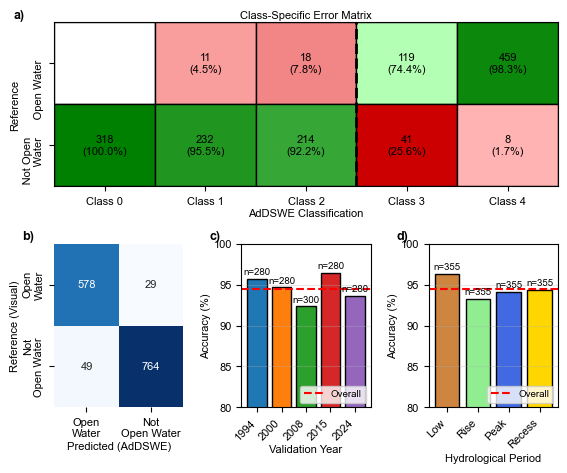


KEY RESULTS:
• OA=94.5%  κ=0.89  n=1420
• PA=95.2%  UA=92.19%
• Temporal σ=1.6%  Seasonal σ=1.3%


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, cohen_kappa_score, accuracy_score
from matplotlib import font_manager

# ============================================================================
# FONT SETUP — embed Arial correctly for Affinity Designer compatibility
# ============================================================================

# Explicitly register Arial from system fonts
font_manager.fontManager.addfont('C:/Windows/Fonts/arial.ttf')

# fonttype=42 embeds TrueType fonts in PDF (correct metrics, editable in AD)
# svg.fonttype='none' keeps SVG text as editable text rather than paths
plt.rcParams.update({
    'font.family':        'Arial',
    'font.size':          8,
    'font.weight':        'normal',
    'axes.labelweight':   'normal',
    'axes.titleweight':   'normal',
    'pdf.fonttype':       42,
    'svg.fonttype':       'none',
})

# ============================================================================
# LOAD DATA
# ============================================================================

BASE_PATH = os.path.join(DRYAD_ROOT, "inundation", "open_water_validation") + os.sep

dfs = []
for year in [1994, 2000, 2007, 2008, 2009, 2015, 2024]:
    try:
        dfs.append(pd.read_csv(f'{BASE_PATH}validation_results_{year}.csv'))
    except FileNotFoundError:
        pass

df = pd.concat(dfs, ignore_index=True)
df['Predicted_Binary'] = df['DSWE_Value'].apply(lambda x: 'Open Water' if x in [3, 4] else 'Not Open Water')

# ============================================================================
# METRICS
# ============================================================================

y_true, y_pred = df['Visual_Classification'], df['Predicted_Binary']
cm = confusion_matrix(y_true, y_pred, labels=['Open Water', 'Not Open Water'])
tp = cm[0, 0]  # Reference OW, Predicted OW
fn = cm[0, 1]  # Reference OW, Predicted NOW
fp = cm[1, 0]  # Reference NOW, Predicted OW
tn = cm[1, 1]  # Reference NOW, Predicted NOW
oa    = accuracy_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)
pa    = tp / (tp + fn)  # producer's accuracy
ua    = tp / (tp + fp)  # user's accuracy
print(f"OA={oa*100:.2f}%  κ={kappa:.4f}  PA={pa*100:.2f}%  UA={ua*100:.2f}%")

# Temporal metrics
df['Year_Group'] = df['Year'].apply(lambda x: '2008' if x in [2007, 2008, 2009] else str(x))
year_metrics = [
    {'Year': yg, 'Accuracy': accuracy_score(df.loc[df.Year_Group==yg, 'Visual_Classification'],
                                             df.loc[df.Year_Group==yg, 'Predicted_Binary']),
     'n': (df.Year_Group==yg).sum()}
    for yg in ['1994','2000','2008','2015','2024'] if (df.Year_Group==yg).any()
]
ym = pd.DataFrame(year_metrics)
year_std = ym['Accuracy'].std()

# Seasonal metrics
df['Month_Group'] = df['Month'].apply(lambda x: 'Low' if x in [1, 12] else x)
month_metrics = [
    {'Label': lbl, 'Accuracy': accuracy_score(df.loc[df.Month_Group==mg, 'Visual_Classification'],
                                               df.loc[df.Month_Group==mg, 'Predicted_Binary']),
     'n': (df.Month_Group==mg).sum()}
    for mg, lbl in [('Low','Low'), (4,'Rise'), (7,'Peak'), (10,'Recess')] if (df.Month_Group==mg).any()
]
mm = pd.DataFrame(month_metrics)
month_std = mm['Accuracy'].std()

# Class-specific matrix
cmat = pd.DataFrame(0,   index=['Open Water','Not Open Water'], columns=[f'Class {i}' for i in range(5)])
cpct = pd.DataFrame(0.0, index=['Open Water','Not Open Water'], columns=[f'Class {i}' for i in range(5)])
for _, row in df.iterrows():
    cmat.loc[row['Visual_Classification'], f'Class {row["DSWE_Value"]}'] += 1
for col in cmat.columns:
    if cmat[col].sum() > 0:
        cpct[col] = cmat[col] / cmat[col].sum()

correct_pcts   = [cpct.loc[r, f'Class {j}'] for r in ['Open Water','Not Open Water'] for j in range(5)
                  if cpct.loc[r, f'Class {j}'] > 0 and ((r=='Open Water') == (j in [3,4]))]
incorrect_pcts = [cpct.loc[r, f'Class {j}'] for r in ['Open Water','Not Open Water'] for j in range(5)
                  if cpct.loc[r, f'Class {j}'] > 0 and ((r=='Open Water') != (j in [3,4]))]
lo_c, hi_c = min(correct_pcts), max(correct_pcts)
lo_e, hi_e = min(incorrect_pcts), max(incorrect_pcts)

# ============================================================================
# FIGURE
# ============================================================================

fig = plt.figure(figsize=(6.5, 5.0))
outer = gridspec.GridSpec(2, 1, figure=fig, hspace=0.35, height_ratios=[1, 1])
ax_a  = fig.add_subplot(outer[0])
bot   = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=outer[1], wspace=0.45)
ax_b, ax_c, ax_d = fig.add_subplot(bot[0]), fig.add_subplot(bot[1]), fig.add_subplot(bot[2])

# --- a) Class-Specific Error Matrix ---
for i, ref in enumerate(['Open Water', 'Not Open Water']):
    for j in range(5):
        pct = cpct.iloc[i, j]
        is_correct = (ref == 'Open Water') == (j in [3, 4])
        if pct == 0:
            color = [1, 1, 1]
        elif is_correct:
            t = (pct - lo_c) / (hi_c - lo_c) if hi_c > lo_c else 1.0
            color = [0.7 - t*0.7, 1.0 - t*0.5, 0.7 - t*0.7]
        else:
            t = (pct - lo_e) / (hi_e - lo_e) if hi_e > lo_e else 1.0
            color = [1.0 - t*0.2, 0.7 - t*0.7, 0.7 - t*0.7]
        ax_a.add_patch(plt.Rectangle((j, i), 1, 1, facecolor=color, edgecolor='black', linewidth=1))
        if cmat.iloc[i, j] > 0:
            ax_a.text(j+0.5, i+0.5, f'{cmat.iloc[i,j]}\n({pct*100:.1f}%)', ha='center', va='center', fontsize=8)

ax_a.set(xlim=(0,5), ylim=(0,2),
         xticks=[0.5,1.5,2.5,3.5,4.5], xticklabels=['Class 0','Class 1','Class 2','Class 3','Class 4'],
         yticks=[0.5,1.5], yticklabels=['     Open Water','     Not Open\n     Water'])
ax_a.set_xlabel('AdDSWE Classification', fontsize=8, labelpad=2)
ax_a.set_ylabel('Reference', fontsize=8, labelpad=2)
ax_a.set_title('Class-Specific Error Matrix', fontsize=8, pad=3)
ax_a.tick_params(labelsize=8)
ax_a.yaxis.set_tick_params(rotation=90)
ax_a.invert_yaxis()
ax_a.axvline(x=3, color='black', linestyle='--', linewidth=2, zorder=10)
ax_a.text(-0.08, 1.08, 'a)', transform=ax_a.transAxes, fontsize=9, fontweight='bold', va='top')

# --- b) Binary Confusion Matrix ---
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax_b,
            xticklabels=['Open\nWater','Not\nOpen Water'],
            yticklabels=['Open\nWater','Not\nOpen Water'],
            annot_kws={'size': 8})
ax_b.set_xlabel('Predicted (AdDSWE)', fontsize=8, labelpad=2)
ax_b.set_ylabel('Reference (Visual)', fontsize=8, labelpad=2)
ax_b.tick_params(labelsize=8)
ax_b.text(-0.25, 1.08, 'b)', transform=ax_b.transAxes, fontsize=9, fontweight='bold', va='top')

# --- c) Temporal Consistency ---
bars_c = ax_c.bar(range(len(ym)), ym['Accuracy']*100,
                  color=['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd'],
                  edgecolor='black', linewidth=1)
ax_c.axhline(y=oa*100, color='red', linestyle='--', linewidth=1.5, label='Overall')
ax_c.set_xticks(range(len(ym)))
ax_c.set_xticklabels(ym['Year'], fontsize=8, rotation=45, ha='right')
ax_c.set_ylabel('Accuracy (%)', fontsize=8, labelpad=2)
ax_c.set_xlabel('Validation Year', fontsize=8, labelpad=2)
ax_c.set_ylim([80, 100])
ax_c.grid(axis='y', alpha=0.3)
ax_c.legend(loc='lower right', fontsize=7)
ax_c.tick_params(labelsize=8)
for bar, row in zip(bars_c, ym.itertuples()):
    ax_c.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
              f'n={row.n}', ha='center', va='bottom', fontsize=7)
ax_c.text(-0.25, 1.08, 'c)', transform=ax_c.transAxes, fontsize=9, fontweight='bold', va='top')

# --- d) Seasonal Consistency ---
bars_d = ax_d.bar(range(len(mm)), mm['Accuracy']*100,
                  color=['#CD853F','#90EE90','#4169E1','#FFD700'],
                  edgecolor='black', linewidth=1)
ax_d.axhline(y=oa*100, color='red', linestyle='--', linewidth=1.5, label='Overall')
ax_d.set_xticks(range(len(mm)))
ax_d.set_xticklabels(mm['Label'], fontsize=8, rotation=45, ha='right')
ax_d.set_ylabel('Accuracy (%)', fontsize=8, labelpad=2)
ax_d.set_xlabel('Hydrological Period', fontsize=8, labelpad=2)
ax_d.set_ylim([80, 100])
ax_d.grid(axis='y', alpha=0.3)
ax_d.legend(loc='lower right', fontsize=7)
ax_d.tick_params(labelsize=8)
for bar, row in zip(bars_d, mm.itertuples()):
    ax_d.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
              f'n={row.n}', ha='center', va='bottom', fontsize=7)
ax_d.text(-0.25, 1.08, 'd)', transform=ax_d.transAxes, fontsize=9, fontweight='bold', va='top')

# ============================================================================
# SAVE — high-res PNG, print-quality PDF, and editable SVG
# ============================================================================

# PNG: 1000 dpi for high-resolution raster use
plt.savefig(f'{OUTPUT_DIR}/validation_figure.png', dpi=1000, bbox_inches='tight')

# PDF: TrueType-embedded (pdf.fonttype=42 set above), suitable for AD import
plt.savefig(f'{OUTPUT_DIR}/validation_figure.pdf', bbox_inches='tight')

# SVG: text kept as editable text nodes (svg.fonttype='none' set above)
plt.savefig(f'{OUTPUT_DIR}/validation_figure.svg', bbox_inches='tight')

plt.show()

print(f"\nKEY RESULTS:")
print(f"\u2022 OA={oa*100:.1f}%  \u03ba={kappa:.2f}  n={len(df)}")
print(f"\u2022 PA={pa*100:.1f}%  UA={ua*100:.2f}%")
print(f"\u2022 Temporal \u03c3={year_std*100:.1f}%  Seasonal \u03c3={month_std*100:.1f}%")

## Table S1 with supplementary Open water validation results

CSV saved.


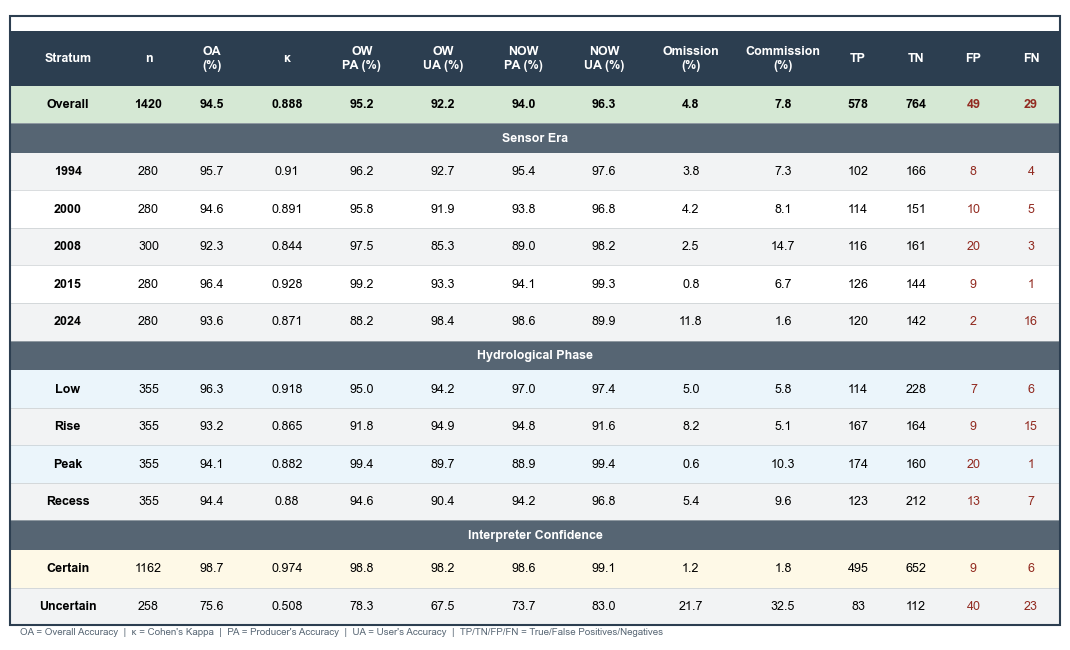

Table S1 saved as PNG, SVG, PDF, and CSV.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import FancyBboxPatch
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix

# ============================================================================
# CONFIGURATION
# ============================================================================

BASE_PATH = os.path.join(DRYAD_ROOT, "inundation", "open_water_validation") + os.sep
OUT_PATH  = OUTPUT_DIR + os.sep  # outputs (change if desired)

YEARS     = [1994, 2000, 2007, 2008, 2009, 2015, 2024]
ERA_MAP   = {1994:'1994', 2000:'2000', 2007:'2008',
             2008:'2008', 2009:'2008', 2015:'2015', 2024:'2024'}
ERA_ORDER = ['1994','2000','2008','2015','2024']
PHASE_MAP   = {1:'Low', 4:'Rise', 7:'Peak', 10:'Recess', 12:'Low'}
PHASE_ORDER = ['Low','Rise','Peak','Recess']
CONF_ORDER  = ['Certain','Uncertain']

# ============================================================================
# LOAD AND PREPARE
# ============================================================================

dfs = []
for year in YEARS:
    try:
        dfs.append(pd.read_csv(f'{BASE_PATH}validation_results_{year}.csv'))
    except FileNotFoundError:
        print(f'  WARNING: validation_results_{year}.csv not found — skipping.')

df = pd.concat(dfs, ignore_index=True)
df['Predicted_Binary'] = df['DSWE_Value'].apply(
    lambda x: 'Open Water' if x in [3, 4] else 'Not Open Water'
)
df['Era']   = df['Year'].map(ERA_MAP)
df['Phase'] = df['Month'].map(PHASE_MAP)

# ============================================================================
# HELPER — compute full metric set for a subset
# ============================================================================

def metrics(sub):
    """Return dict of all accuracy metrics for a dataframe subset."""
    yt = sub['Visual_Classification']
    yp = sub['Predicted_Binary']
    cm = confusion_matrix(yt, yp, labels=['Open Water', 'Not Open Water'])
    tp = cm[0, 0]  # Reference OW, Predicted OW
    fn = cm[0, 1]  # Reference OW, Predicted NOW
    fp = cm[1, 0]  # Reference NOW, Predicted OW
    tn = cm[1, 1]  # Reference NOW, Predicted NOW
    oa   = accuracy_score(yt, yp)
    kap  = cohen_kappa_score(yt, yp)
    pa_w = tp / (tp + fn) if (tp + fn) > 0 else np.nan  # OW producer's
    ua_w = tp / (tp + fp) if (tp + fp) > 0 else np.nan  # OW user's
    pa_n = tn / (tn + fp) if (tn + fp) > 0 else np.nan  # NOW producer's
    ua_n = tn / (tn + fn) if (tn + fn) > 0 else np.nan  # NOW user's
    oe   = fn / (tp + fn) if (tp + fn) > 0 else np.nan  # omission error
    ce   = fp / (tp + fp) if (tp + fp) > 0 else np.nan  # commission error
    return {
        'n': len(sub),
        'OA (%)':         round(oa  * 100, 1),
        'κ':              round(kap, 3),
        'OW PA (%)':      round(pa_w * 100, 1),
        'OW UA (%)':      round(ua_w * 100, 1),
        'NOW PA (%)':     round(pa_n * 100, 1),
        'NOW UA (%)':     round(ua_n * 100, 1),
        'Omission (%)':   round(oe  * 100, 1),
        'Commission (%)': round(ce  * 100, 1),
        'TP': int(tp), 'TN': int(tn),
        'FP': int(fp), 'FN': int(fn),
    }

# ============================================================================
# COMPUTE METRICS
# ============================================================================

rows = []

# 1. Overall
r = metrics(df)
r['Stratum'] = 'Overall'
r['Category'] = 'Overall'
rows.append(r)

# 2. Per sensor era
for era in ERA_ORDER:
    sub = df[df['Era'] == era]
    if len(sub) > 0:
        r = metrics(sub)
        r['Stratum']  = era
        r['Category'] = 'Sensor Era'
        rows.append(r)

# 3. Per hydrological phase
for phase in PHASE_ORDER:
    sub = df[df['Phase'] == phase]
    if len(sub) > 0:
        r = metrics(sub)
        r['Stratum']  = phase
        r['Category'] = 'Hydrological Phase'
        rows.append(r)

# 4. Per confidence flag
for conf in CONF_ORDER:
    sub = df[df['Confidence_Flag'] == conf]
    if len(sub) > 0:
        r = metrics(sub)
        r['Stratum']  = conf
        r['Category'] = 'Interpreter Confidence'
        rows.append(r)

results_df = pd.DataFrame(rows)
col_order  = ['Category','Stratum','n',
              'OA (%)','κ',
              'OW PA (%)','OW UA (%)',
              'NOW PA (%)','NOW UA (%)',
              'Omission (%)','Commission (%)',
              'TP','TN','FP','FN']
results_df = results_df[col_order]

# ============================================================================
# EXPORT — unformatted CSV
# ============================================================================

results_df.to_csv(f'{OUT_PATH}Table_S1.csv', index=False)
print("CSV saved.")

# ============================================================================
# FORMATTED TABLE FIGURE
# ============================================================================

# Display columns (abbreviate for space)
display_cols = ['Stratum','n','OA (%)','κ',
                'OW PA (%)','OW UA (%)',
                'NOW PA (%)','NOW UA (%)',
                'Omission (%)','Commission (%)',
                'TP','TN','FP','FN']

# Section labels and row groupings
section_labels = {
    'Overall':               None,
    'Sensor Era':            'Sensor Era',
    'Hydrological Phase':    'Hydrological Phase',
    'Interpreter Confidence':'Interpreter Confidence',
}

# ── figure setup ────────────────────────────────────────────────────────────

FONT      = 'Arial'
FS        = 9        # body font size
FS_HEAD   = 9        # header font size
ROW_H     = 0.38     # inches per data row
HEAD_H    = 0.55     # header row height
SEP_H     = 0.30     # section separator height

# Count rows including separators
n_data_rows = len(results_df)
n_seps      = len(results_df['Category'].unique()) - 1  # separators between groups
fig_h       = HEAD_H + n_data_rows * ROW_H + n_seps * SEP_H + 0.3  # 0.3 padding
fig_w       = 10.5

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.set_axis_off()

plt.rcParams.update({
    'font.family': FONT,
    'font.size':   FS,
})

# Column widths (proportional, must sum to 1)
col_widths = {
    'Stratum':        0.10,
    'n':              0.04,
    'OA (%)':         0.07,
    'κ':              0.06,
    'OW PA (%)':      0.07,
    'OW UA (%)':      0.07,
    'NOW PA (%)':     0.07,
    'NOW UA (%)':     0.07,
    'Omission (%)':   0.08,
    'Commission (%)': 0.08,
    'TP':             0.05,
    'TN':             0.05,
    'FP':             0.05,
    'FN':             0.05,
}
# Normalise in case they don't sum to exactly 1
total_w = sum(col_widths.values())
col_widths = {k: v / total_w for k, v in col_widths.items()}

# Compute cumulative x positions (0–1 in axes coords)
x_positions = {}
cum = 0.0
for col in display_cols:
    x_positions[col] = cum + col_widths[col] / 2   # centre of column
    cum += col_widths[col]

# ── draw header ─────────────────────────────────────────────────────────────

header_labels = {
    'Stratum':        'Stratum',
    'n':              'n',
    'OA (%)':         'OA\n(%)',
    'κ':              'κ',
    'OW PA (%)':      'OW\nPA (%)',
    'OW UA (%)':      'OW\nUA (%)',
    'NOW PA (%)':     'NOW\nPA (%)',
    'NOW UA (%)':     'NOW\nUA (%)',
    'Omission (%)':   'Omission\n(%)',
    'Commission (%)': 'Commission\n(%)',
    'TP':             'TP',
    'TN':             'TN',
    'FP':             'FP',
    'FN':             'FN',
}

# Map y: we'll work in figure inches then convert to axes fraction
total_h = fig_h

def y_frac(y_inch):
    """Convert y position in inches from top to axes fraction."""
    return 1.0 - (y_inch / total_h)

y_cursor = 0.15  # inches from top, starting after top padding

# Header background
ax.add_patch(plt.Rectangle(
    (0, y_frac(y_cursor + HEAD_H)), 1, HEAD_H / total_h,
    facecolor='#2C3E50', transform=ax.transAxes, clip_on=False, zorder=2
))

for col in display_cols:
    ax.text(
        x_positions[col], y_frac(y_cursor + HEAD_H / 2),
        header_labels[col],
        ha='center', va='center', fontsize=FS_HEAD,
        fontfamily=FONT, color='white', fontweight='bold',
        transform=ax.transAxes, clip_on=False, zorder=3,
        linespacing=1.2
    )

y_cursor += HEAD_H

# ── draw data rows ───────────────────────────────────────────────────────────

# Colour scheme
COLORS = {
    'Overall':               '#D5E8D4',   # soft green
    'Sensor Era':            '#FFFFFF',   # white
    'Hydrological Phase':    '#EBF5FB',   # soft blue
    'Interpreter Confidence':'#FEF9E7',   # soft yellow
}
SECTION_HEADER_COLOR = '#566573'

prev_category = None
row_idx       = 0

for _, row in results_df.iterrows():
    cat = row['Category']

    # Section separator row
    if cat != prev_category and prev_category is not None:
        ax.add_patch(plt.Rectangle(
            (0, y_frac(y_cursor + SEP_H)), 1, SEP_H / total_h,
            facecolor=SECTION_HEADER_COLOR,
            transform=ax.transAxes, clip_on=False, zorder=2
        ))
        ax.text(
            0.5, y_frac(y_cursor + SEP_H / 2),
            cat,
            ha='center', va='center', fontsize=FS,
            fontfamily=FONT, color='white', fontweight='bold',
            transform=ax.transAxes, clip_on=False, zorder=3
        )
        y_cursor += SEP_H
    elif prev_category is None and cat != 'Overall':
        # First section header (shouldn't occur with Overall first, but safety)
        pass

    # Alternating row background within non-Overall sections
    if cat == 'Overall':
        bg = COLORS['Overall']
    else:
        bg = COLORS[cat] if row_idx % 2 == 0 else '#F2F3F4'

    ax.add_patch(plt.Rectangle(
        (0, y_frac(y_cursor + ROW_H)), 1, ROW_H / total_h,
        facecolor=bg,
        transform=ax.transAxes, clip_on=False, zorder=1
    ))

    # Draw cell values
    for col in display_cols:
        val = row[col]
        # Bold the Stratum column; bold Overall row
        fw = 'bold' if (col == 'Stratum' or cat == 'Overall') else 'normal'
        # Highlight FP/FN in muted red if non-zero
        fc = '#922B21' if col in ['FP','FN'] and val > 0 else 'black'
        ax.text(
            x_positions[col], y_frac(y_cursor + ROW_H / 2),
            str(val),
            ha='center', va='center', fontsize=FS,
            fontfamily=FONT, color=fc, fontweight=fw,
            transform=ax.transAxes, clip_on=False, zorder=3
        )

    # Thin horizontal rule between rows
    ax.plot(
        [0, 1], [y_frac(y_cursor + ROW_H), y_frac(y_cursor + ROW_H)],
        color='#BDC3C7', linewidth=0.4,
        transform=ax.transAxes, clip_on=False, zorder=4
    )

    y_cursor += ROW_H
    prev_category = cat
    row_idx += 1

# Outer border
for spine in ['top','bottom','left','right']:
    ax.spines[spine].set_visible(False)
rect = plt.Rectangle((0, y_frac(y_cursor)), 1, 1 - y_frac(y_cursor),
                      fill=False, edgecolor='#2C3E50', linewidth=1.5,
                      transform=ax.transAxes, clip_on=False, zorder=5)
ax.add_patch(rect)

# Column header: group labels above OW and NOW columns
ax.text(
    (x_positions['OW PA (%)'] + x_positions['OW UA (%)']) / 2,
    y_frac(0.02),
    'Open Water (OW)',
    ha='center', va='bottom', fontsize=7, fontfamily=FONT,
    color='white', style='italic',
    transform=ax.transAxes, clip_on=False
)
ax.text(
    (x_positions['NOW PA (%)'] + x_positions['NOW UA (%)']) / 2,
    y_frac(0.02),
    'Not Open Water (NOW)',
    ha='center', va='bottom', fontsize=7, fontfamily=FONT,
    color='white', style='italic',
    transform=ax.transAxes, clip_on=False
)

# Caption
fig.text(
    0.01, 0.005,
    'OA = Overall Accuracy  |  κ = Cohen\'s Kappa  |  PA = Producer\'s Accuracy  |  '
    'UA = User\'s Accuracy  |  TP/TN/FP/FN = True/False Positives/Negatives',
    fontsize=7, fontfamily=FONT, color='#566573', va='bottom'
)

plt.tight_layout(pad=0)

# ============================================================================
# SAVE
# ============================================================================

fig.savefig(f'{OUT_PATH}Table_S1.png', dpi=1000, bbox_inches='tight')
fig.savefig(f'{OUT_PATH}Table_S1.svg',           bbox_inches='tight')
fig.savefig(f'{OUT_PATH}Table_S1.pdf',           bbox_inches='tight')
plt.show()
print("Table S1 saved as PNG, SVG, PDF, and CSV.")

In [5]:
import os
print(f"BASE_PATH exists: {os.path.exists(BASE_PATH)}")
print(f"Contents of BASE_PATH:")
if os.path.exists(BASE_PATH):
    for f in sorted(os.listdir(BASE_PATH)):
        print(f"  {f}")

BASE_PATH exists: False
Contents of BASE_PATH:
